# Исследовательский анализ рынка общественного питания в г.Москва
---

### Цели и задачи проекта

Цель - провести исследовательский анализ рынка общественного питания Москвы. Результаты анализа необходимы инвесторам, для выбора подходящего места и будущего меню. Особое внимание следует уделить категориям заведений, выделить ТОП по рейтингу среди посетителей, что на него влияет, а так же посчитать средний чек на разные районы Москвы. 

### Описание данных

Файл `rest_info.csv` содержит информацию о заведениях общественного питания:

- `name` — название заведения;

- `address` — адрес заведения;

- `district` — административный район, в котором находится заведение, например Центральный административный округ;

- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;

- `hours` — информация о днях и часах работы;

- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — `5.0`);

- `chain`— число, выраженное `0` или `1`, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):

  - `0` — заведение не является сетевым;
  - `1` — заведение является сетевым.

- `seats` — количество посадочных мест.

Файл `rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;

- `avg_bill`— строка, которая хранит среднюю стоимость заказа в виде диапазона, например:

  - «Средний счёт: 1000–1500 ₽»;

  - «Цена чашки капучино: 130–220 ₽»;

  - «Цена бокала пива: 400–600 ₽».

    и так далее;

- `middle_avg_bill`— число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:

  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.

- `middle_coffee_cup`— число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:

  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними.   
2. Предобработка данных.  
3. Исследовательский анализ данных.  
4. Итоговый вывод и рекомендации
---

## 1. Загрузка данных и знакомство с ними


In [1]:
# Импортируем библиотеки в проект
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

In [ ]:
# Загружаем данные из CSV файла в DataFrame
df_info_orig = pd.read_csv('секретная_информация/rest_info.csv')
df_price_orig = pd.read_csv('секретная_информация/rest_price.csv')

# Создаем копии DataFrame для работы
df_info = df_info_orig.copy()
df_price = df_price_orig.copy()

In [3]:
# Выведем общую информацию о данных
print('Информация о df_info:')
display(df_info.info())
print('Информация о df_price:')
display(df_price.info())

Информация о df_info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


None

Информация о df_price:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


None

---

### Промежуточный вывод


Мы будем работать с данными о заведениях общественного питания Москвы. Данные содержатся в двух файлах: `rest_info.csv` и `rest_price.csv`.  
По полученным данным понятно, что `df_info` содержит информацию о заведениях, а `df_price` - информацию о ценах в этих заведениях. Есть общий столбец `id`, по которому можно объединить эти два набора данных.  
Так же в данных есть пропуски, которые нужно будет обработать. Некоторые столбцы имеют тип данных`object. Это тоже нужно будет исправить.

### Подготовка единого датафрейма


In [4]:
# Объединим два датафрейма по столбцу 'id', но так, что бы не потерять строки из df_info
df_merged = df_info.merge(df_price, on='id', how='left')

In [5]:
# Выведем первые 10 строк объединенного датафрейма
display(df_merged.head(10))
df_merged.info()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0,средние,Средний счёт:199 ₽,199.0,NaN
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0,средние,Средний счёт:200–300 ₽,250.0,NaN
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0,средние,Средний счёт:от 500 ₽,500.0,NaN
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0,средние,Средний счёт:1000–1200 ₽,1100.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


## 2. Предобработка данных


In [6]:
# Выведем типы данных в объединенном датафрейме
display(df_merged.dtypes)

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

In [7]:
# Приведем столбцы 'name', 'address', 'hours', 'avg_bill', 'district' к типу 'string'
df_merged['name'] = df_merged['name'].astype('string')
df_merged['address'] = df_merged['address'].astype('string')
df_merged['hours'] = df_merged['hours'].astype('string')
df_merged['avg_bill'] = df_merged['avg_bill'].astype('string')
df_merged['district'] = df_merged['district'].astype('string')

In [8]:
# Столбцы 'category', 'district', 'price' к типу 'category'
df_merged['category'] = df_merged['category'].astype('category')
df_merged['price'] = df_merged['price'].astype('category')

In [9]:
# Столбец 'chain' к оптимальному типу для хранения 1 или 0
df_merged['chain'] = df_merged['chain'].astype('boolean')

In [10]:
# Столбец 'seats' к типу 'Int' 
df_merged['seats'] = df_merged['seats'].astype('Int64')

In [11]:
# Проверим изменения типов данных
display(df_merged.dtypes)

id                           object
name                 string[python]
category                   category
address              string[python]
district             string[python]
hours                string[python]
rating                      float64
chain                       boolean
seats                         Int64
price                      category
avg_bill             string[python]
middle_avg_bill             float64
middle_coffee_cup           float64
dtype: object

In [12]:
# Посчитаем пропуски в данных и долю пропусков в процентах
missing_data = pd.DataFrame({
    'missing_count': df_merged.isna().sum(),
    'missing_share %': df_merged.isna().mean() * 100
}).sort_values(by='missing_share %', ascending=False)
display(missing_data)

,missing_count,missing_share %
middle_coffee_cup,7871,93.635498
middle_avg_bill,5257,62.538663
price,5091,60.563883
avg_bill,4590,54.603854
seats,3611,42.957411
hours,536,6.376398
id,0,0.000000
name,0,0.000000
category,0,0.000000
address,0,0.000000


In [13]:
# Проверим категории заведений с пропусками по столбцу 'seats'
seats_missing = df_merged[df_merged['seats'].isna()]['category'].value_counts()
display(seats_missing)

category
кафе               1160
ресторан            773
кофейня             662
бар,паб             297
быстрое питание     254
пиццерия            206
столовая            151
булочная            108
Name: count, dtype: int64

In [14]:
# Т.к. поле 'id' уникально идентифицирует заведения, проверим по нему наличие явных дубликатов
print('Количество неявных дубликатов по id:', df_merged['id'].duplicated().sum())

# Проверим наличие неявных дубликатов по столбцам 'name' и 'address'
print('Количество неявных дубликатов по name и address:', df_merged.duplicated(subset=['name', 'address']).sum())
      

Количество неявных дубликатов по id: 0
Количество неявных дубликатов по name и address: 0


In [15]:
# Выведем эти дубликаты, если они есть
if df_merged.duplicated(subset=['name', 'address']).sum() > 0:
    display(df_merged[df_merged.duplicated(subset=['name', 'address'], keep=False)].sort_values(by=['name', 'address']))  

In [16]:
# Удалим неявные дубликаты, оставив первые вхождения
df_merged = df_merged.drop_duplicates(subset=['name', 'address'], keep='first').reset_index(drop=True)
print('Количество строк в датафрейме после удаления неявных дубликатов:', df_merged.shape[0])

Количество строк в датафрейме после удаления неявных дубликатов: 8406


In [17]:
# Првоерим категориальные столбцы на наличие дубликатов. Выведем уникальные значения
print('Уникальные значения в столбце category:', df_merged['category'].unique())
print('Уникальные значения в столбце district:', df_merged['district'].unique())
print('Уникальные значения в столбце price:', df_merged['price'].unique()) 

Уникальные значения в столбце category: ['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']
Categories (8, object): ['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']
Уникальные значения в столбце district: <StringArray>
[        'Северный административный округ',
 'Северо-Восточный административный округ',
  'Северо-Западный административный округ',
         'Западный административный округ',
      'Центральный административный округ',
        'Восточный административный округ',
    'Юго-Восточный административный округ',
            'Южный административный округ',
     'Юго-Западный административный округ']
Length: 9, dtype: string
Уникальные значения в столбце price: [NaN, 'выше среднего', 'средние', 'высокие', 'низкие']
Categories (4, object): ['высокие', 'выше среднего', 'низкие', 'средние']


In [18]:
# Создадим новый столбец 'is_24_7'. Если заведение работает ежедневно и круглосуточно, в этом столбце будет True, иначе False
df_merged['is_24_7'] = df_merged['hours'].str.contains('ежедневно, круглосуточно', case = False, na = False)

In [19]:
# Посчитаем круглосуточные заведения
num_24_7 = df_merged['is_24_7'].sum()
print('Количество круглосуточных заведений:', num_24_7)

Количество круглосуточных заведений: 730


---

### Промежуточный вывод



Первичная предобработка данных показала, что большая доля пропусков имеется в столбцах, связанных со стоимостью среднего чека и чашки кофе.   
Скорее всего это связано с тем, что не все заведения предоставляют такую информацию, а кофе не является основным продуктов в большинстве заведений.   
Пропуски в информации о числе посадочных мест могут присутствовать, по причине технического сбоя, либо из за отсутствия посадочных мест, например в кофейнях, где готовят кофе на вынос.   
`По требованию задания пропуски ни как не изменяем.`  
При поиске дубликатов было обнаружено 3 строки, имеющие уникальные `id`, но идентичные `name`, `address`. Принято решение удалить повторы, оставив первые вхождения.    
Для анализа дубликатов в категориальных значениях были выведены все уникальные значения, повторов не обнаружено.   
Добавлен столбец `is_24_7` для дальнейшего анализа круглосуточных заведений.  

## 3. Исследовательский анализ данных


---

### Задача 1

Проверим категориии

In [20]:
# Выведем количество заведений по категориям, рассчитаем долю каждой категории
df_category_count = pd.DataFrame(df_merged['category'].value_counts().reset_index())
df_category_count.columns = ['category', 'count']
df_category_count['share'] = (df_category_count['count'] / df_category_count['count'].sum() * 100).round(2)
display(df_category_count)

,category,count,share
0,кафе,2378,28.29
1,ресторан,2043,24.30
2,кофейня,1413,16.81
3,"бар,паб",765,9.10
4,пиццерия,633,7.53
5,быстрое питание,603,7.17
6,столовая,315,3.75
7,булочная,256,3.05


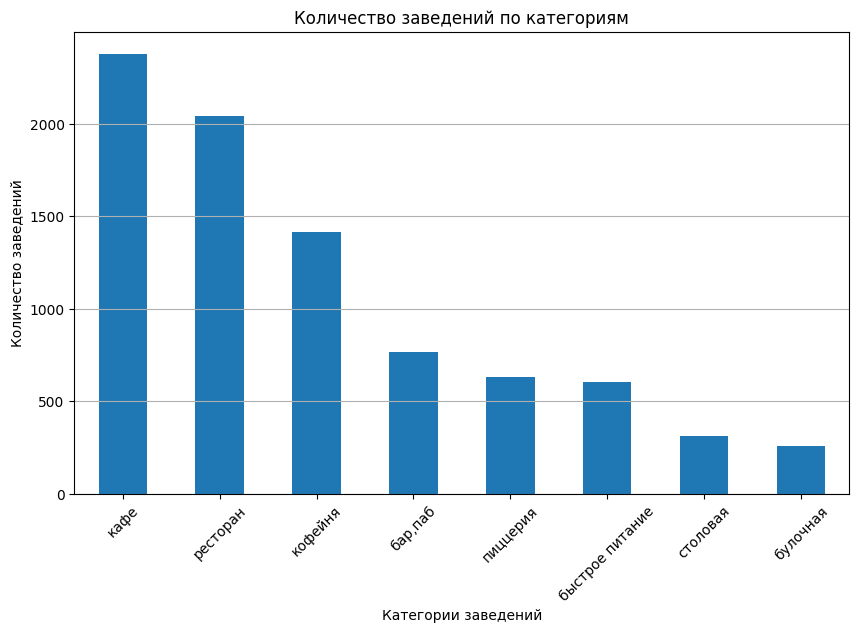

In [21]:
# Отобразим количество заведений по категориям на графике, используем столбчатую диаграмму
category_plt = df_category_count.plot(kind = 'bar', x = 'category', y = 'count', rot = 45, figsize = (10, 6), legend = False)

plt.title('Количество заведений по категориям')
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

### Промежуточный вывод

Самые популярные категории - кафе, рестораны и кофейни. Это может быть обусловлено популярностью среди клиентов,    
низким порогом вхождения (за исключением ресторанов), но не стоит забывать и про более высокую конкуренцию.

---

### Задача 2
Исследуем районы

In [22]:
# Посчитаем и выведем количество заведений по районам, рассчитаем долю каждого района
df_district_counst = pd.DataFrame(df_merged['district'].value_counts().reset_index())
df_district_counst.columns = ['district', 'count']
df_district_counst['share'] = df_district_counst['count'] / df_district_counst['count'].sum()
display(df_district_counst)

,district,count,share
0,Центральный административный округ,2242,0.266714
1,Северный административный округ,900,0.107066
2,Южный административный округ,892,0.106115
3,Северо-Восточный административный округ,891,0.105996
4,Западный административный округ,851,0.101237
5,Восточный административный округ,798,0.094932
6,Юго-Восточный административный округ,714,0.084939
7,Юго-Западный административный округ,709,0.084345
8,Северо-Западный административный округ,409,0.048656


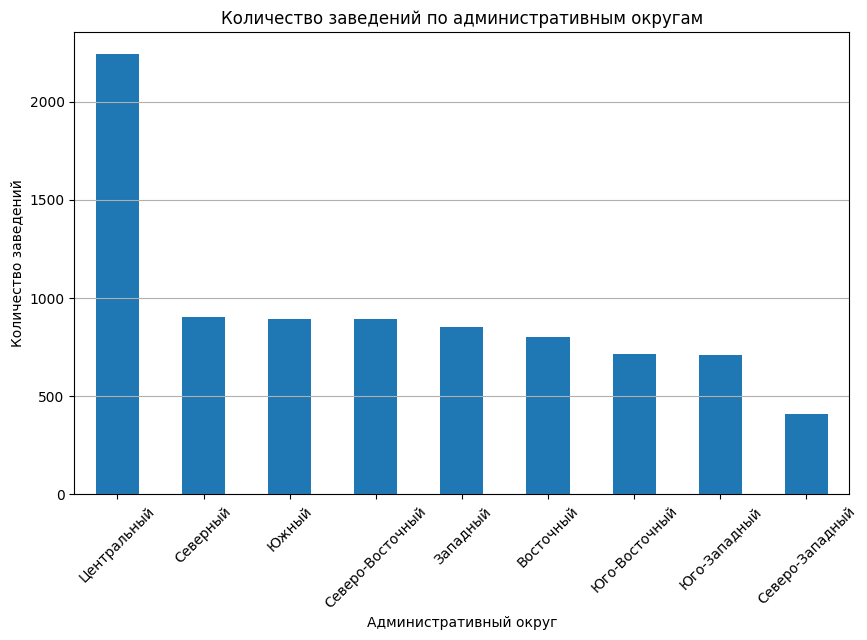

In [23]:
# Для удобства отображения скоратим названия, убрав "административный округ"
df_district_counst['district'] = df_district_counst['district'].str.replace(' административный округ', '', regex=False)

# Отобразим результаты в столбчатой диаграмме
district_plt = df_district_counst.plot(kind = 'bar', x = 'district', y = 'count', rot = 45, figsize = (10, 6), legend = False)

plt.title('Количество заведений по административным округам')
plt.xlabel('Административный округ')
plt.ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

In [24]:
# Выведем категории заведений с количеством, сгруппировав по районам
df_category_district = df_merged.pivot_table(index = 'district', columns = 'category', values = 'id', aggfunc = 'count')
display(df_category_district)

/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_77546/2512737920.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_category_district = df_merged.pivot_table(index = 'district', columns = 'category', values = 'id', aggfunc = 'count')


category,"бар,паб",булочная,быстрое питание,кафе,кофейня,пиццерия,ресторан,столовая
district,,,,,,,,
Восточный административный округ,53,25,71,272,105,72,160,40
Западный административный округ,50,37,62,239,150,71,218,24
Северный административный округ,68,39,58,235,193,77,189,41
Северо-Восточный административный округ,63,28,82,269,159,68,182,40
Северо-Западный административный округ,23,12,30,115,62,40,109,18
Центральный административный округ,364,50,87,464,428,113,670,66
Юго-Восточный административный округ,38,13,67,282,89,55,145,25
Юго-Западный административный округ,38,27,61,238,96,64,168,17
Южный административный округ,68,25,85,264,131,73,202,44


In [25]:
# Для удобства отображения сократим названия, убрав "административный округ"
df_category_district.index = df_category_district.index.str.replace(' административный округ', '', regex=False)

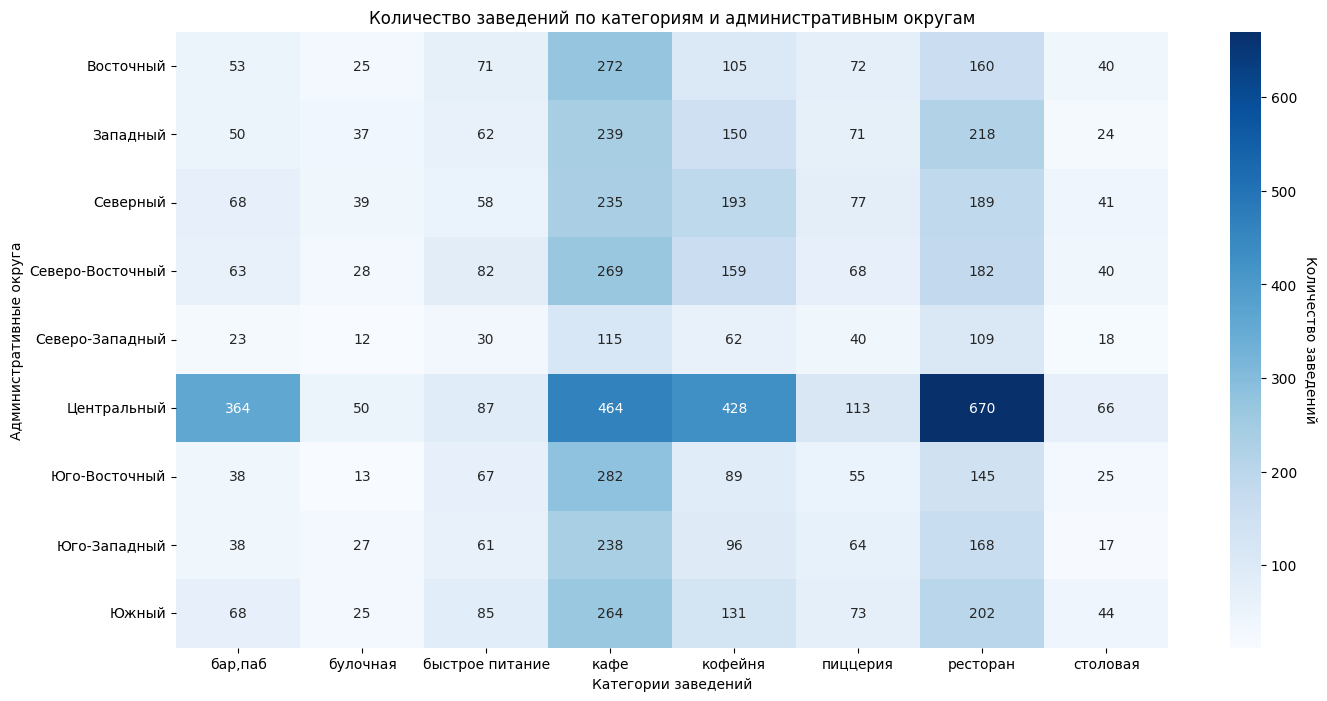

In [26]:
# Построим тепловую карту для наглядного отображения количества заведений по категориям и районам
plt.figure(figsize=(16, 8))
sns.heatmap(df_category_district, annot=True, fmt = 'g', cmap='Blues')
plt.title('Количество заведений по категориям и административным округам')
plt.xlabel('Категории заведений')
plt.ylabel('Административные округа')


cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Количество заведений', rotation=270, labelpad=15)

plt.show()


### Промежуточный вывод

Самое большое количество заведений в ЦАО. В центре высокий туристический поток, чаще проводят свой досуг местные жители. Спрос всегда рождает прдложение.   
Самая поплярная категория по оличеству заведений - ресторан, на втором месте кафе, и затем кофейня.   
Стоит так же отметить, что количество кафе стабильно высокое практически во всех округах Москвы. 

---

### Задача 3
Изучаем сетевые и несетевые заведения

In [27]:
# Посчитаем количество сетевых и несетвых заведений в целом
networked_counts = df_merged['chain'].agg(
    [lambda x: (x==0).sum(), 
    'sum',
    lambda x: (x.mean() * 100).round(2)]
)

networked_counts.index = ['Несетевые', 'Сетевые', 'Доля сетевых, %']
networked_counts.name = 'Количество'

display(pd.DataFrame(networked_counts))

,Количество
Несетевые,5201.00
Сетевые,3205.00
"Доля сетевых, %",38.13


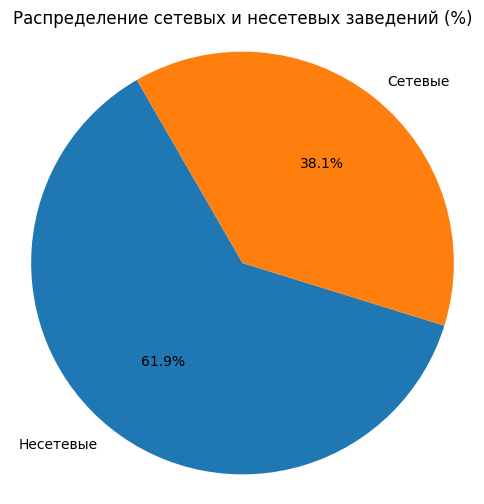

In [28]:
# Создадим круговувую диаграмму и опреджелим долю сетевых и несетевых заведений
networked_counts_plot = networked_counts[:-1].plot(kind = 'pie', autopct='%1.1f%%', startangle=120, figsize = (6, 6), legend = False)

plt.title('Распределение сетевых и несетевых заведений (%)')
plt.axis('equal')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [29]:
# Создадим таблицу по категориям и сетевым/несетевым заведениям
networked_by_category = df_merged.groupby('category')['chain'].agg(['count', 'sum', lambda x: (x.mean() * 100).round(2)])
networked_by_category = networked_by_category.sort_values(by='count', ascending=False)

networked_by_category.columns = ['Несетевые', 'Сетевые', 'Доля сетевых, %']
display(networked_by_category)

/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_77546/3601805664.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  networked_by_category = df_merged.groupby('category')['chain'].agg(['count', 'sum', lambda x: (x.mean() * 100).round(2)])


,Несетевые,Сетевые,"Доля сетевых, %"
category,,,
кафе,2378,779,32.76
ресторан,2043,730,35.73
кофейня,1413,720,50.96
"бар,паб",765,169,22.09
пиццерия,633,330,52.13
быстрое питание,603,232,38.47
столовая,315,88,27.94
булочная,256,157,61.33


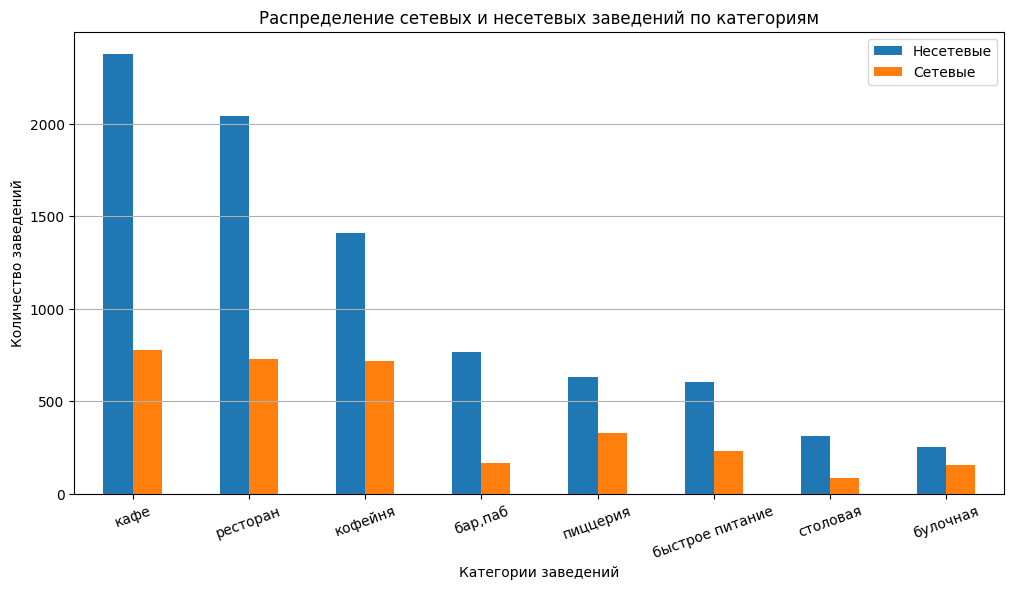

In [30]:
# Построим график распределения сетевых и несетвых заведений по категориям
networked_by_category_plt = networked_by_category.drop(columns='Доля сетевых, %') # Столбец с долей не нужен на графике
ax = networked_by_category_plt.plot(kind = 'bar', rot = 20, figsize = (12, 6))

plt.title('Распределение сетевых и несетевых заведений по категориям')
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

### Промежуточный вывод

Самые популярные категории - кафе, рестораны и кофейни. Такие категории проще открывать в сетевом формате, что бы поддерживать общий стиль, повышать узнаваемость и  лояльность.   
К тому же, на рынке представлено большое количество уже готовых франшиз, что облегчает вход и позволяет пользоваться опытом основателей сети. 

---

### Задача 4
Проверим количество посадочных мест

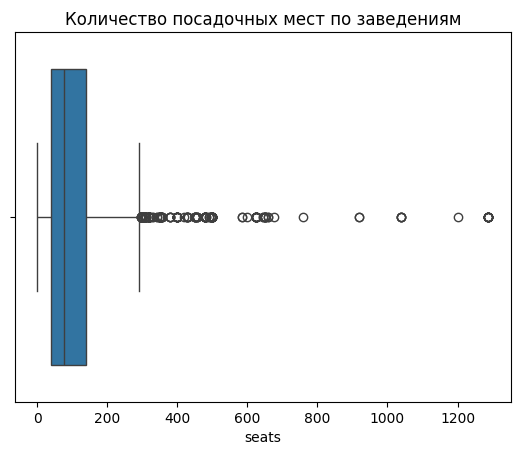

count        4795.0
mean     108.421689
std      122.833396
min             0.0
25%            40.0
50%            75.0
75%           140.0
max          1288.0
Name: seats, dtype: Float64

In [31]:
# Построим диаграмму размаха по количеству мест в заведениях
sns.boxplot(data = df_merged, x = 'seats')
plt.title('Количество посадочных мест по заведениям')
plt.show()
df_merged['seats'].describe()


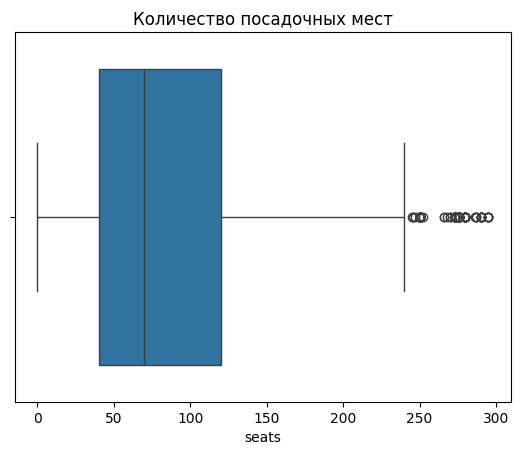

count       4482.0
mean     84.837573
std      66.189603
min            0.0
25%           40.0
50%           70.0
75%          120.0
max          295.0
Name: seats, dtype: Float64

In [32]:
# Как видно по диаграмме, данные имеют очень сильный сдвиг вправо, что говорит о наличии выбросов в данных. Отфильтруем количество посадочных мест выше 300,
# что бы снизить влияние выбросов на общие показатели
df_seats_filtered = df_merged[df_merged['seats'] < 300]
sns.boxplot(data = df_seats_filtered, x = 'seats')
plt.title('Количество посадочных мест')
plt.show()
df_seats_filtered['seats'].describe()

In [33]:
# Для каждой категории выведем наиболее часто повторяющееся значения количества посадочных мест
df_seats_category = df_seats_filtered.groupby('category')['seats'].agg('mean').astype('Int64')
df_seats_category = df_seats_category.sort_values(ascending=False)
display(df_seats_category)

/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_77546/812149016.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_seats_category = df_seats_filtered.groupby('category')['seats'].agg('mean').astype('Int64')


category
ресторан           96
бар,паб            88
кофейня            85
быстрое питание    81
столовая           78
булочная           76
кафе               76
пиццерия           76
Name: seats, dtype: Int64

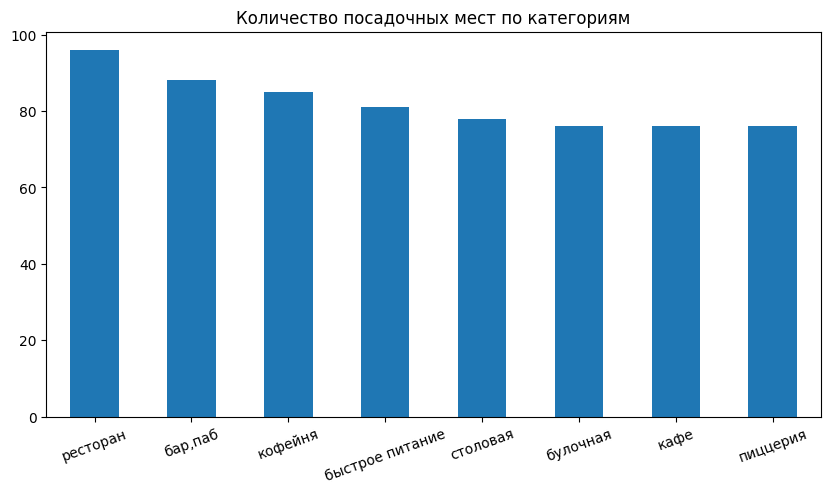

In [34]:
# Отобразим результаты на графике
df_seats_category.plot(kind='bar', figsize = (10, 5), rot = 20)
plt.title('Количество посадочных мест по категориям')
plt.xlabel('')
plt.show()

### Промежуточный вывод

На первом месте ресторан, с количеством посадочных мест 96.    
На втором бар/паб - 88. На третьем кофейня - 85. Однако не стоит забывать о большом количестве выбросов в данных. Для более точного анализа необходимо уточнение данных о количестве посадочных мест.

---

### Задача 5
Исследуем рейтинг заведений

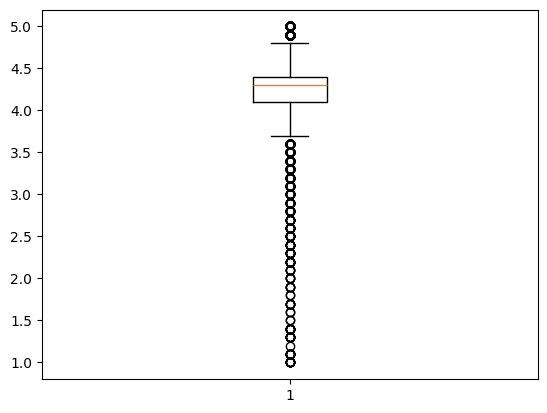

In [35]:
# Построим диаграмму размаха для рейтинга всех заведений, что бы определить выбросы
plt.boxplot(df_merged['rating'])
plt.show()

In [36]:
# Выведем информацию о столбце
display(df_merged['rating'].describe())

count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

##### !!!
По диаграмме можно предположить наличие выбросов, но зная о наличии низких и высоких оценок,   
по краткой информации можно утверждать, что выбросов или аномальных значений нет.

In [37]:
# Узнаем средние значения рейтинга для категорий заведений
rating_category = pd.DataFrame(df_merged.groupby('category')['rating'].mean().round(2))
# отсортируем по убыванию
rating_category = rating_category.sort_values(by='rating', ascending=False)

display(rating_category)

/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_77546/2796690873.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_category = pd.DataFrame(df_merged.groupby('category')['rating'].mean().round(2))


,rating
category,
"бар,паб",4.39
пиццерия,4.30
ресторан,4.29
кофейня,4.28
булочная,4.27
столовая,4.21
кафе,4.12
быстрое питание,4.05


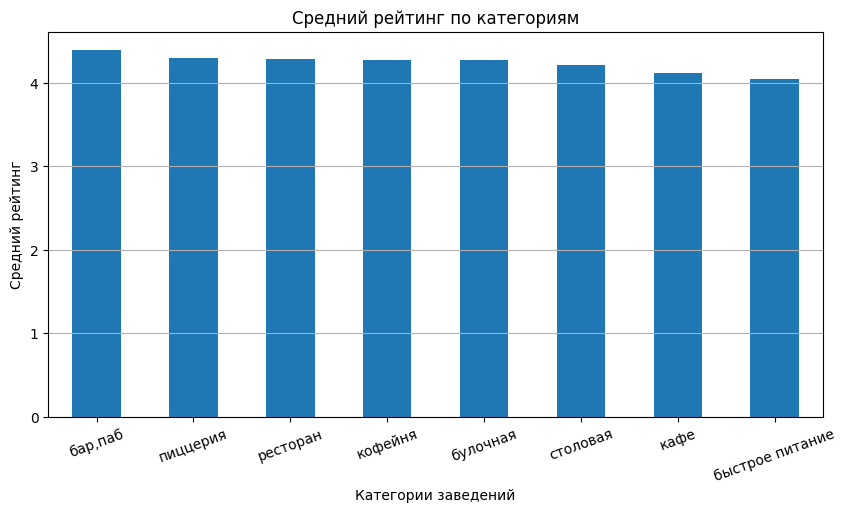

In [38]:
# Отобразим средний рейтинг по категориям на графике
rating_category.plot(kind = 'bar', figsize = (10, 5), rot = 20, legend = False)
plt.title('Средний рейтинг по категориям')
plt.xlabel('Категории заведений')
plt.ylabel('Средний рейтинг')
plt.grid(axis = 'y')
plt.show()

### Промежуточный вывод

На первом месте по оценкам бар/паб, на втором пиццерия, на третьем ресторан.   
Возможно, это обусловлено тем, что такие места оставляют у клиентов более сильные эмоции, нежели булочная или быстрое питание.   
Так же, нельзя утверждать и обратное - отсутствие оценок не говорит о плохом впечатлении о заведении у клиентов. 

---

### Задача 6
Корреляция рейтинга с остальными данными

In [41]:
# Подготовым стобцы 
selected_columns = ['category', 'district', 'chain', 'price', 'is_24_7', 'rating']

In [42]:
# Создадим матрицу корреляции рейтинга заведения с разными данными, с помощью phik
# Отфильтруем данные, исключив маркеры -1 (пропуски)
filtered_df = df_merged.loc[(df_merged['seats'] >= 0) & (df_merged['price'].notnull())][selected_columns].copy()

# Преобразуем boolean в int, что бы исключить ошибки приведения типов
filtered_df['chain'] = filtered_df['chain'].astype(int)
filtered_df['is_24_7'] = filtered_df['is_24_7'].astype(int)

# Создаем матрицу
corr_matrix = filtered_df.phik_matrix(interval_cols=['rating'])

corr_matrix_heatmap = corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by = 'rating', ascending=False)


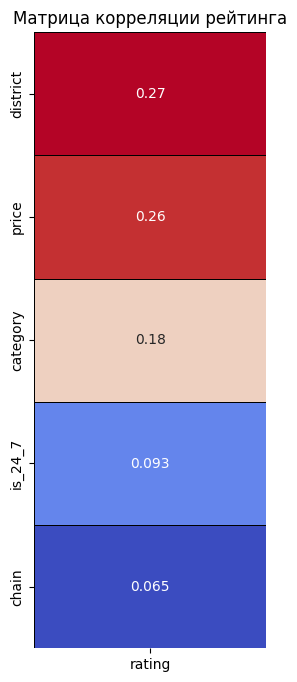

In [43]:
# Выведем тепловую карту
plt.figure(figsize=(3, 8))
sns.heatmap(corr_matrix_heatmap, annot=True, cmap='coolwarm', cbar=False, linewidths=0.5, linecolor='black')
plt.title('Матрица корреляции рейтинга')
plt.show()

#####
Судя по матрице, самая сильная связь - между рейтингом и районом. Проверим ее

In [44]:

# Что бы проверить связь между рейтингом и районом, посчитаем количество оценок по районам и средний рейтинг по районам
rating_district = df_merged.pivot_table(index = 'district', values = 'rating', aggfunc = ['count', 'mean']).round(2)
rating_district.columns = ['Количество оценок', 'Средний рейтинг']
rating_district = rating_district.sort_values(by='Средний рейтинг', ascending=False)
display(rating_district)


,Количество оценок,Средний рейтинг
district,,
Центральный административный округ,2242,4.38
Северный административный округ,900,4.24
Северо-Западный административный округ,409,4.21
Западный административный округ,851,4.18
Южный административный округ,892,4.18
Восточный административный округ,798,4.17
Юго-Западный административный округ,709,4.17
Северо-Восточный административный округ,891,4.15
Юго-Восточный административный округ,714,4.10


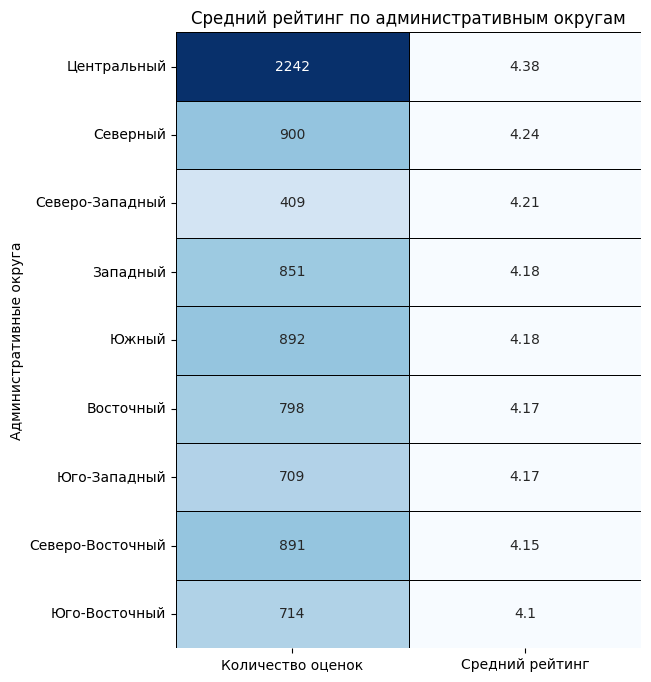

In [45]:
# Отобразим средний рейтинг по районам на тепловой карте
plt.figure(figsize=(6, 8))

# Уберем из названий районов "административный округ", что бы не загромождать график
rating_district.index = rating_district.index.str.replace(' административный округ', '', regex=False)

sns.heatmap(rating_district, annot=True, cmap='Blues', cbar=False, linewidths=0.5, linecolor='black', fmt='g')
plt.title('Средний рейтинг по административным округам')
plt.xlabel('')
plt.ylabel('Административные округа')
plt.show()


### Промежуточный вывод

Самое большое количество оценок - Центральный административный округ, он же имеет самую высокую среднюю оценку. Связь между районом и рейтингом заведения подтверждена

---

### Задача 7
Топ - 15 популярных сетей общественного питания


In [46]:
# Посчитамем топ - 15 сетевых заведений по всей Москве. Выведем их названия, категорию, количество заведений в сети и средний рейтинг
top_15_chains = df_merged[df_merged['chain'] == 1].groupby(['name', 'category']).agg({'id': 'count', 'rating': 'mean'}).reset_index().round(2)
top_15_chains.columns = ['Название', 'Категория', 'Количество заведений в сети', 'Средний рейтинг']
top_15_chains = top_15_chains.sort_values(by='Количество заведений в сети', ascending=False).head(15)
display(top_15_chains)


/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_77546/567892511.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_15_chains = df_merged[df_merged['chain'] == 1].groupby(['name', 'category']).agg({'id': 'count', 'rating': 'mean'}).reset_index().round(2)


,Название,Категория,Количество заведений в сети,Средний рейтинг
5972,Шоколадница,кофейня,119,4.18
2757,Домино'с Пицца,пиццерия,76,4.17
2725,Додо Пицца,пиццерия,74,4.29
1188,One Price Coffee,кофейня,71,4.06
6078,Яндекс Лавка,ресторан,69,3.87
476,Cofix,кофейня,65,4.08
1366,Prime,ресторан,49,4.11
3028,КОФЕПОРТ,кофейня,42,4.15
3451,Кулинарная лавка братьев Караваевых,кафе,39,4.39
5150,Теремок,ресторан,36,4.11


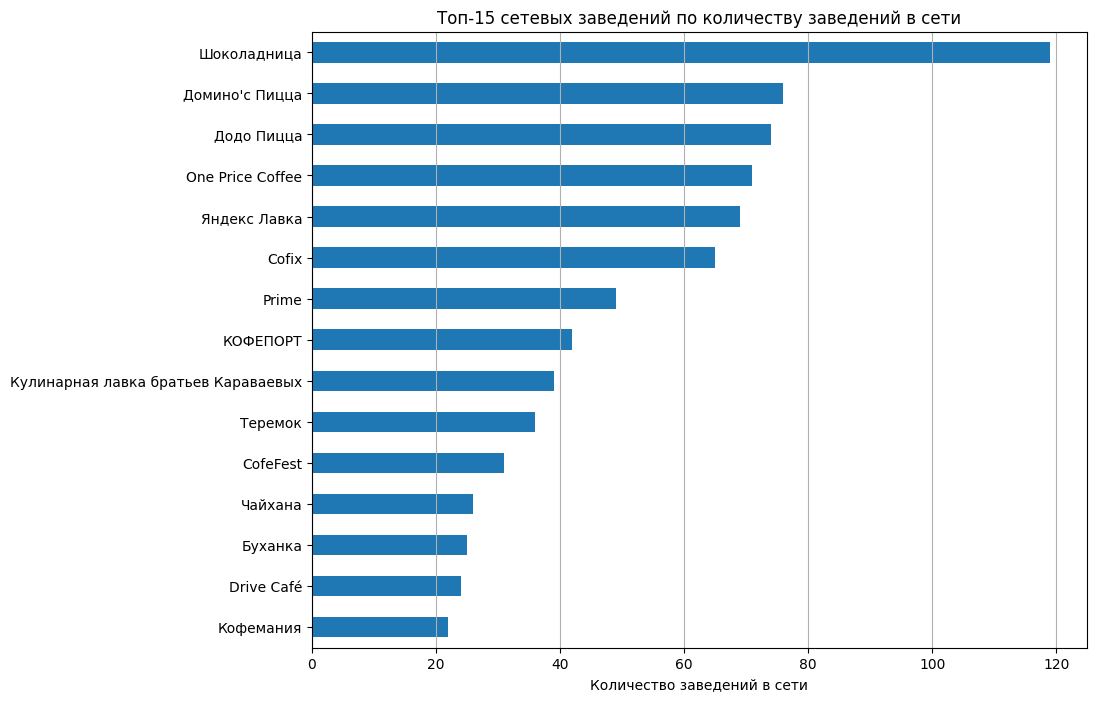

In [47]:
# Отобразим топ-15 сетевых заведений на горизонтальной столбчатой диаграмме
top_15_chains_plot = top_15_chains.plot(kind='barh', x='Название', y='Количество заведений в сети', figsize=(10, 8), legend=False)
top_15_chains_plot.invert_yaxis()  

plt.title('Топ-15 сетевых заведений по количеству заведений в сети')
plt.ylabel('')
plt.xlabel('Количество заведений в сети')
plt.grid(axis='x')
plt.show()


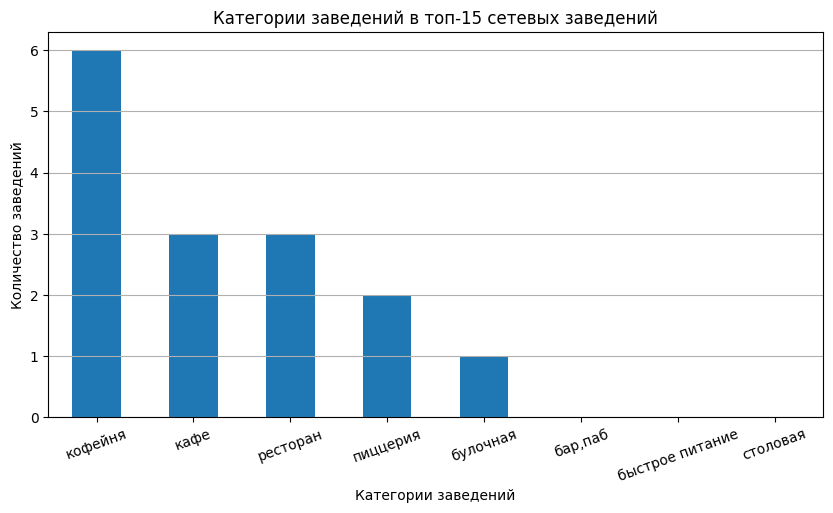

In [48]:

# Посчитаем, какие категории чаще всего используются в сетевых заведениях из нашего списка топ - 15
top_15_chains_category = top_15_chains['Категория'].value_counts()

# Отобразим результаты на графике
top_15_chains_category_plot = top_15_chains_category.plot(kind = 'bar', rot = 20, figsize = (10, 5), legend = False)

plt.title('Категории заведений в топ-15 сетевых заведений')
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

### Промежуточный вывод

Самая большая сеть заведений - `Шоколадница`. На втором месте `Домино'с Пицца` и на третьем - `Додо Пицца`.  
Самые распространенные категории среди топовых сетевых заведений - `кофейня`, `кафе`, `ресторан`

---

### Задача 8



In [49]:
# Сгруппируем данные по районам, что бы изучить вариацию срднего чека 'middle_avg_bill'
# Отфильтруем маркеры и приведём тип
df_bill = df_merged[df_merged['middle_avg_bill'] != '-1'].copy()
df_bill['middle_avg_bill'] = pd.to_numeric(df_bill['middle_avg_bill'], errors='coerce')
df_bill = df_bill.dropna(subset=['middle_avg_bill'])

bill_district = df_bill.pivot_table(index='district', values='middle_avg_bill', aggfunc = ['median', 'min', 'max', 'mean']).round(2)

bill_district.columns = ['Медианное значение', 'Минимальный средний чек', 'Максимальный средний чек', 'Средний чек']

bill_district = bill_district.sort_values(by='Медианное значение', ascending=False)

display(bill_district)

,Медианное значение,Минимальный средний чек,Максимальный средний чек,Средний чек
district,,,,
Западный административный округ,1000.0,50.0,5250.0,1053.23
Центральный административный округ,1000.0,0.0,7250.0,1191.06
Северо-Западный административный округ,700.0,120.0,2900.0,822.22
Северный административный округ,650.0,130.0,11000.0,927.96
Юго-Западный административный округ,600.0,100.0,2750.0,792.56
Восточный административный округ,575.0,50.0,10000.0,820.63
Северо-Восточный административный округ,500.0,50.0,4500.0,716.61
Южный административный округ,500.0,100.0,35000.0,834.40
Юго-Восточный административный округ,450.0,30.0,3750.0,654.10



Мы использовали медиану вместо среднего значения, что бы измебжать искажений данных и искусственного повышения среднего чека.   
По результату видим, что лидируют Западный и Центральный административный округ.  
Так же стоит отметить, что медиана понижается по мере удаления от Цнтрального округа. 

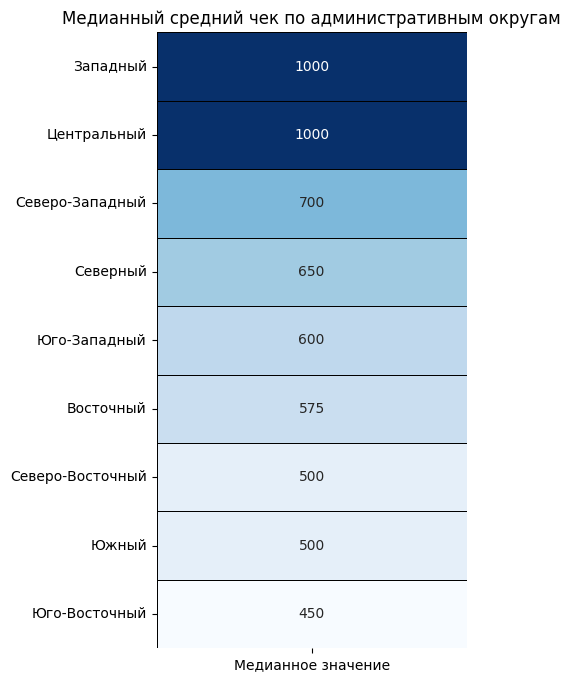

In [50]:
# Уберем из названий районов "административный округ", что бы не загромождать график
bill_district.index = bill_district.index.str.replace(' административный округ', '', regex=False)

# Построим тепловую карту для наглядного отображения медианного среднего чека по районам
plt.figure(figsize=(4, 8))
sns.heatmap(bill_district[['Медианное значение']], annot = True, cmap = 'Blues', cbar = False, linewidths = 0.5, linecolor='black', fmt='g')
plt.title('Медианный средний чек по административным округам')
plt.xlabel('')
plt.ylabel('')
plt.show()


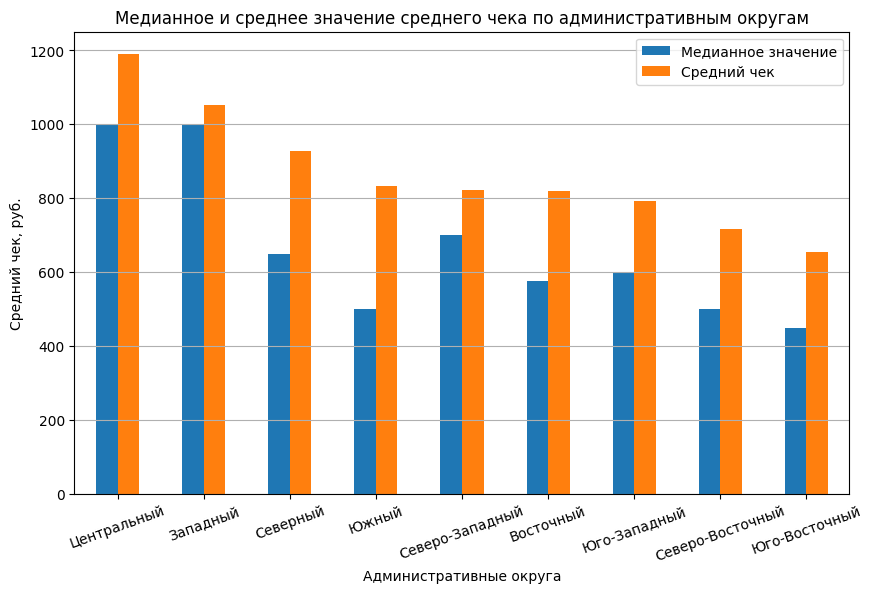

In [51]:
# Отобразим медианное значение и среднее значение среднего чека по районам на одном графике для сравнения
bill_district = bill_district.sort_values(by='Средний чек', ascending=False)
bill_district[['Медианное значение', 'Средний чек']].plot(kind='bar', figsize=(10, 6), rot=20)

plt.title('Медианное и среднее значение среднего чека по административным округам')
plt.xlabel('Административные округа')
plt.ylabel('Средний чек, руб.')
plt.grid(axis='y')
plt.show()

---


---

### Промежуточный вывод по всем задачам



По полученной информации можно сделать следующие промежуточные выводы:
1. В данных присутствуют пропуски, их происхождение следует рассматривать в частном порядке. Возможны технические ошибки при сборе данных.
2. В данных нет явных дубликатов, неявные дубликаты по 'name' и 'address' были удалены, что улучшило качество данных.
3. Категориальный столбец 'category' содержит 8 уникальных значений, что позволяет провести детальный анализ по категориям заведений.
4. Большинство заведений расположены в Центральном административном округе, что может быть связано с высокой плотностью населения и туристической активностью в этом районе.
5. Сетевые заведения составляют около 38,13% от общего числа заведений, при этом доля сетевых заведений значительно варьируется по категориям.   
Например, в категории "кофейня" доля сетевых заведений составляет около 50%, тогда как в категории "бар, паб" - 22%.
6. Анализ количества посадочных мест показал наличие выбросов, особенно в заведениях с более чем 300 местами. После фильтрации выбросов, наиболее   
типичное количество посадочных мест варьируется по категориям, например, в кафе это 76 мест, в ресторанах - 96 мест.

## 4. Итоговый вывод и рекомендации

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

#### Общий обзор результатов анализа.  

1. В данных присутствуют пропуски, некоторые из них можно объяснить спецификой заведений (например, отсутствие посадочных мест в булочных и заведениях быстрого питания).  

2. В данных нет явных дубликатов, неявные дубликаты по 'name' и 'address' были удалены, что улучшило качество данных.

#### Ответы на исследовательские вопросы.  

1. Существует 8 основных категорий заведений - кафе, ресторан, бар/паб, кофейня, быстрое питание, булочная, столовая.  
Топ по количеству заведений занимают кафе (28%), рестораны (24%) и кофейни (около 17%)
2. В данных представлено 9 административных округов Москвы, с наибольшим количеством заведений в Центральном (около 27%). На втором месте Северный, Южный и Северо-Восточный округа (около 12% у каждого).  
В Центральном районе самое большое количество ресторанов, кофейн, кафе и баров/пабов. С очень большим отрывом от остальных районов, в среднем в  5-6 раз.   
3. Количество несетевых превышает количество сетевых. Доля сетевых заведений от общего количества составляет всего 38%.   
Объяснить это можно тем, что заведения общепита открывают многие начинающие бизнесмены, которые не имеют возможности сразу создать сеть заведений.  
В топ - 3 сетевых заведений входят булочные, кафейни и пиццерии. Возможно, это связано с популярностью этих категорий и их доступностью для франчайзинга. А так же низким порогом входа на рынок.  
4. В данных о количестве посадочных мест много выбросов и аномальных значений, трудно дать четкое определение или сделать выводы.   
По имеющимся данным мможно сказать, что ресторан требует наибольшее количество посадочных мест (в среднем 100), а булочная и кофейня может и вовсе обойтись без них.  
отсюда вытекает следующее требование - большая площадь для открытия ресторана, и меньшая для булочной или кофейни.  
Такие маленькие заведения удобно открывать в торговых центрах, на вокзалах, в аэропортах и других местах с высокой проходимостью.  
5. Средний рейтинг по категориям почти на одном уровне, с незначительным отрывом в пользу баров/пабов, булочных и пиццерий.   
6. Самая сильная связь рейтинга наблюдается с категорией "цена" (0.21), что логично, так как клиентам важна ценовая политика. 
Все же нужно заметить, что корреляция есть и с другими данными - "район" (0.19), "категория" (0.19). 
7. Топ - 15 сетевых заведений по количеству заведений в сети возглавляют кофейни и пиццерии. В таких заведениях, как правило, низкий порог входа на рынок, что позволяет быстро развиваться и открывать новые точки.  
Еще у них выслкая проходимость, довольно высокий средний чек и возможность работать в формате доставки.   
не стоит забывать о том, что клиенты не задерживаются в таких заведениях надолго, что позволяет обслуживать большее количество клиентов за единицу времени.   
8. Для выборки по средним чека использовалось медианное значение, что бы снизить влияние выбросов. Самое высокое значение получилось в ЦАО и ЗАО (1000р.),   
но максимальные значения отличаются, ЗАО 5250р и ЦАО 7250р. В центре Москвы клиента чаще и больше готовы потратить на средний чек.  
К тому же, в центральном районе чаще совершают прогулки и развлекаются.  
Если сравнить медианное и среднее значение внутри района, то отличия весьма существенны и средний чек всегда выше. Не исключено влияние аномальных значений, требуется детальное изучение и коррекция первоначальных данных.  

#### Рекомендации на основе анализа.  

Если заведение первое и опыта в подобных проектах нет, то лучше открыть кофейню или пиццерию по франшизе. Это позволит минимизировать риски и воспользоваться уже отработанными бизнес-моделями.  
Так же, стоит обратить внимание на район открытия заведения. Центральный округ имеет наибольший потенциал для привлечения клиентов, но и конкуренция там высока.   
Не нужно забывать и про высокую арендную плату, которая может съесть всю прибыль. Для более качественной оценки стоит провести анализ аренды и соотнести его с ожидаемым доходом.  
Спальные районы могут быть менее конкурентными и более доступными по стоимости аренды, что может быть выгодным для новых заведений.  
Так же, в спальных районах могут быть более полпулярными булочные, кофейни и заведения быстрого питания, что стоит учитывать при выборе концепции заведения.   
А в центральном наоборот, рестораны, кафе и бары/пабы.   
Центральный район более интересен в вопросе проходимости, популярности, но требователен к первоначальным вложениям и качеству обслуживания. А так же там очен ьвысокая конкуренция.